<a href="https://colab.research.google.com/github/sruthi-kurra/fraud-detection-gnn/blob/main/02_graph_construction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Setup: upload data & load clean transactions

In [1]:
import pandas as pd
import numpy as np
from google.colab import files
import zipfile

# Upload the zip again
uploaded = files.upload()

# Extract
with zipfile.ZipFile('ieee-fraud-detection.zip', 'r') as z:
    z.extractall('data/')

# Load and clean in one go
train_txn = pd.read_csv('data/train_transaction.csv')
train_id  = pd.read_csv('data/train_identity.csv')
df = train_txn.merge(train_id, on='TransactionID', how='left')

core_cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
             'card1', 'card4', 'ProductCD',
             'P_emaildomain', 'R_emaildomain', 'addr1', 'isFraud']

df = df[core_cols].copy()
df['addr1'] = df['addr1'].fillna(-1)
df['P_emaildomain'] = df['P_emaildomain'].fillna('unknown')
df['R_emaildomain'] = df['R_emaildomain'].fillna('unknown')
df['card4'] = df['card4'].fillna('unknown')
df['TransactionAmt'] = df['TransactionAmt'].fillna(df['TransactionAmt'].median())

print(f"Shape: {df.shape}")
df.head()

Saving ieee-fraud-detection.zip to ieee-fraud-detection.zip
Shape: (590540, 10)


,TransactionID,TransactionDT,TransactionAmt,card1,card4,ProductCD,P_emaildomain,R_emaildomain,addr1,isFraud
0,2987000,86400,68.5,13926,discover,W,unknown,unknown,315.0,0
1,2987001,86401,29.0,2755,mastercard,W,gmail.com,unknown,325.0,0
2,2987002,86469,59.0,4663,visa,W,outlook.com,unknown,330.0,0
3,2987003,86499,50.0,18132,mastercard,W,yahoo.com,unknown,476.0,0
4,2987004,86506,50.0,4497,mastercard,H,gmail.com,unknown,420.0,0


## Cell 2 — Build node features (each card1 = one account node)

In [2]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns to numbers
le = LabelEncoder()
df['card4_enc']        = le.fit_transform(df['card4'])
df['ProductCD_enc']    = le.fit_transform(df['ProductCD'])
df['P_emaildomain_enc']= le.fit_transform(df['P_emaildomain'])

# Build node-level features by grouping by card1 (each card1 = one account node)
node_features = df.groupby('card1').agg(
    total_transactions = ('TransactionID', 'count'),
    total_amount       = ('TransactionAmt', 'sum'),
    avg_amount         = ('TransactionAmt', 'mean'),
    max_amount         = ('TransactionAmt', 'max'),
    unique_products    = ('ProductCD_enc', 'nunique'),
    unique_emails      = ('P_emaildomain_enc', 'nunique'),
    fraud_label        = ('isFraud', 'max')  # if ANY transaction is fraud, node = fraud
).reset_index()

print(f"Total nodes (accounts): {len(node_features)}")
print(f"Fraudulent nodes: {node_features['fraud_label'].sum()}")
node_features.head()

Total nodes (accounts): 13553
Fraudulent nodes: 1740


,card1,total_transactions,total_amount,avg_amount,max_amount,unique_products,unique_emails,fraud_label
0,1000,1,23.443,23.443000,23.443,1,1,0
1,1001,3,239.000,79.666667,183.000,1,1,0
2,1004,5,682.000,136.400000,226.000,3,3,0
3,1005,1,50.000,50.000000,50.000,1,1,0
4,1006,3,400.000,133.333333,150.000,1,2,0


## Cell 3 — Build edge list (each transaction = one edge between accounts)

In [3]:
# Create a mapping from card1 to node index (0, 1, 2, ...)
card1_to_idx = {card1: idx for idx, card1 in enumerate(node_features['card1'])}

# Build edges — connect accounts that share the same email domain
# This captures fraud rings where multiple cards use the same email
edges = df.groupby('P_emaildomain')['card1'].apply(list).reset_index()

src_nodes = []
dst_nodes = []

for _, row in edges.iterrows():
    accounts = row['card1']
    if len(accounts) > 1:
        for i in range(len(accounts)):
            for j in range(i+1, min(i+5, len(accounts))):  # limit to 5 neighbors
                src = card1_to_idx.get(accounts[i])
                dst = card1_to_idx.get(accounts[j])
                if src is not None and dst is not None:
                    src_nodes.append(src)
                    dst_nodes.append(dst)

print(f"Total edges: {len(src_nodes)}")
print(f"Example edges (src → dst): {list(zip(src_nodes[:5], dst_nodes[:5]))}")

Total edges: 2361560
Example edges (src → dst): [(12198, 876), (12198, 6326), (12198, 11246), (12198, 6615), (876, 6326)]


## Cell 4 — Create PyTorch Geometric graph object

In [4]:
!pip install torch-geometric -q

import torch
from torch_geometric.data import Data
import numpy as np

# Node features matrix (13553 nodes x 6 features)
feature_cols = ['total_transactions', 'total_amount', 'avg_amount',
                'max_amount', 'unique_products', 'unique_emails']

x = torch.tensor(node_features[feature_cols].values, dtype=torch.float)

# Labels (fraud or not for each node)
y = torch.tensor(node_features['fraud_label'].values, dtype=torch.long)

# Edge index (2 x num_edges)
edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)

# Create PyG graph object
data = Data(x=x, edge_index=edge_index, y=y)

print(data)
print(f"\nNode feature matrix shape: {data.x.shape}")
print(f"Edge index shape:          {data.edge_index.shape}")
print(f"Labels shape:              {data.y.shape}")
print(f"Fraud nodes:               {data.y.sum().item()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.6 MB/s eta 0:00:00
Data(x=[13553, 6], edge_index=[2, 2361560], y=[13553])

Node feature matrix shape: torch.Size([13553, 6])
Edge index shape:          torch.Size([2, 2361560])
Labels shape:              torch.Size([13553])
Fraud nodes:               1740


## Cell 5 — Visualize a fraud subgraph


Fraud nodes with 2+ fraud neighbors: 1740
Subgraph nodes: 59, edges: 501


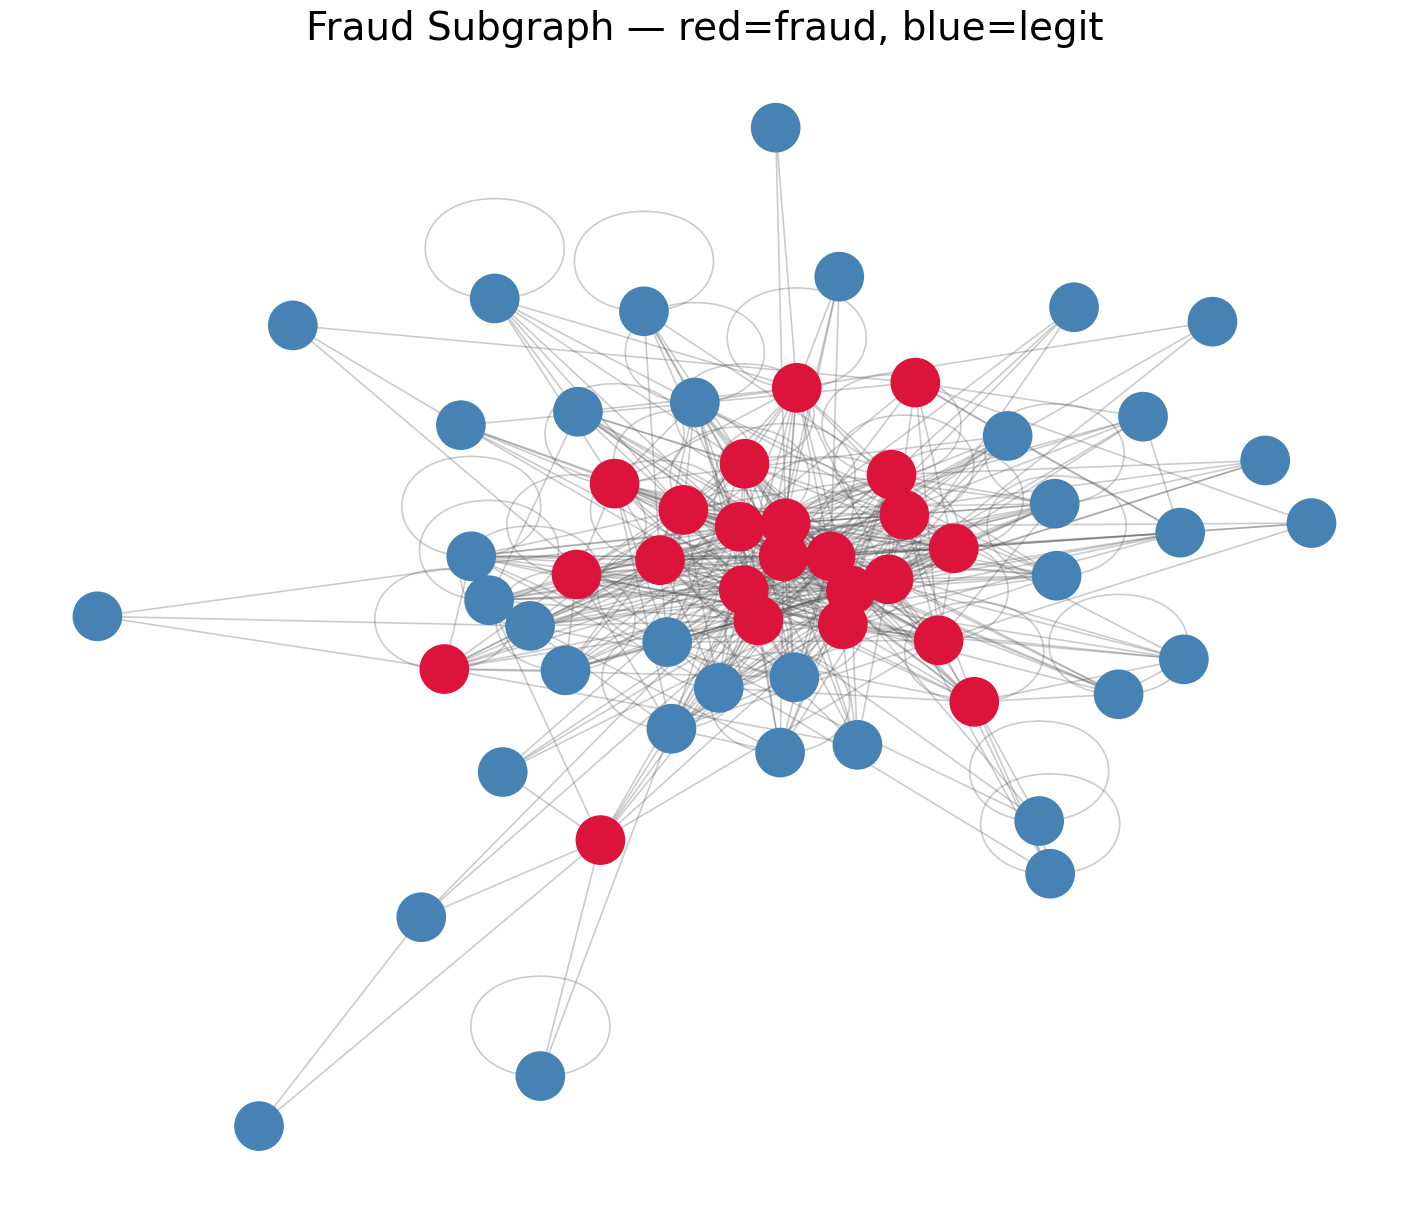

In [9]:
import math
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 1. Build the full graph once
G_full = nx.Graph()
G_full.add_edges_from(zip(src_nodes, dst_nodes))

# 2. Find fraud nodes with 2+ fraud neighbors
fraud_idx_set = set(node_features[node_features['fraud_label'] == 1].index)
candidates = [
    n for n in fraud_idx_set
    if n in G_full and sum(1 for nb in G_full.neighbors(n) if nb in fraud_idx_set) >= 2
]
print(f"Fraud nodes with 2+ fraud neighbors: {len(candidates)}")

# 3. Build seed set — more legit neighbors around the fraud core
seed_nodes = set()
for n in candidates[:6]:
    seed_nodes.add(n)
    neighbors = list(G_full.neighbors(n))
    legit_nb = [nb for nb in neighbors if node_features.iloc[nb]['fraud_label'] == 0]
    fraud_nb = [nb for nb in neighbors if node_features.iloc[nb]['fraud_label'] == 1]
    seed_nodes.update(fraud_nb[:3])
    seed_nodes.update(legit_nb[:6])

G = G_full.subgraph(seed_nodes).copy()
print(f"Subgraph nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")

# 4. Color nodes
node_colors = [
    'crimson' if node_features.iloc[n]['fraud_label'] == 1 else 'steelblue'
    for n in G.nodes()
]

# 5. Spring layout, larger spacing
k_val = 6 / math.sqrt(G.number_of_nodes())
pos = nx.spring_layout(G, k=k_val, iterations=300, seed=42)

# 6. Smaller figure, no axes, no whitespace
fig, ax = plt.subplots(figsize=(7, 6))           # smaller than before (was 12x10)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.6, edge_color='#555555', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=320, linewidths=0, ax=ax)
ax.set_title("Fraud Subgraph — red=fraud, blue=legit", fontsize=14)
ax.set_axis_off()                                 # hide axes completely
ax.margins(0.02)                                  # tiny buffer so nodes aren't clipped

fig.tight_layout(pad=0.2)
fig.savefig("subgraph.png", dpi=200, bbox_inches="tight", pad_inches=0.05)
plt.close(fig)

display(Image("subgraph.png"))

In [10]:
from google.colab import files
files.download('subgraph.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>